# Preamble

In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """
    Function to set matplotlib parameters for plotting.

    Parameters:
    dpi (int): Dots per inch for the plot. Default is 300.
    figsize (tuple): Figure size for the plot. Default is (18, 12).
    grid (bool): Whether to show grid in the plot. Default is True.
    font_size (int): Font size for the text in the plot. Default is 16.
    font_family (str): Font family for the text in the plot. Default is 'serif'.

    Returns:
    None

    This function updates the default parameters in matplotlib's rcParams dictionary to 
    customize the look and feel of matplotlib plots. The parameters include dots per inch (dpi) 
    for plot resolution, figure size, grid visibility, font size, and font family.
    """
    import matplotlib as mpl
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family
set_mpl_params()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Problem 1

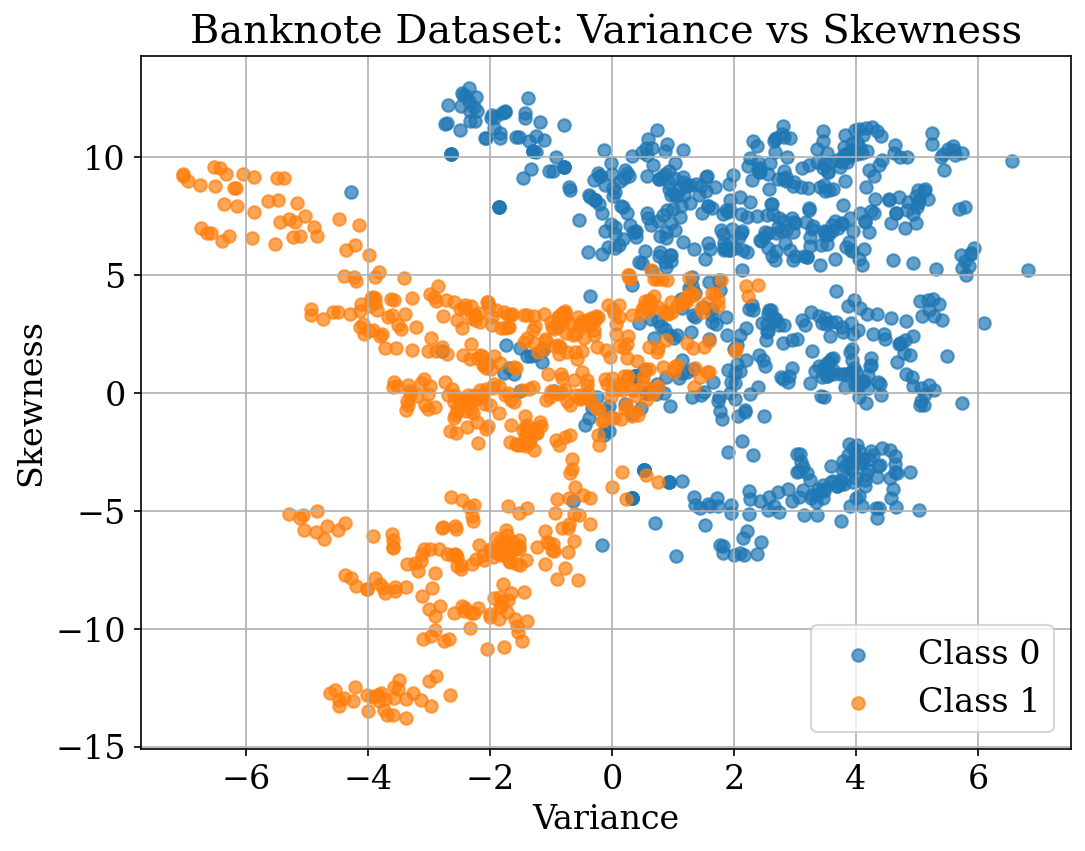

In [3]:
# Load Banknote dataset
source = 'banknote_authentication.csv'
df = pd.read_csv(source, header=None)
X = df[[0, 1]].values # Variance & Skewness features
y = df[4].values

# Scatter plot of the data
plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ['blue', 'orange']):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f'Class {label}', alpha=0.7)
plt.title('Banknote Dataset: Variance vs Skewness')
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
def cubic_hist_classifier(X_train, y_train, bins=3):
    # Create 2D histogram of training data features (X1 and X2)
    hist, x_edges, y_edges = np.histogram2d(X_train[:, 0], X_train[:, 1], bins=bins)
    # Initialize matrix to store majority class for each bin
    bin_classes = np.zeros(hist.shape, dtype=int)

    # Determine majority class in each histogram bin
    for i in range(bins):
        for j in range(bins):
            # Create mask for current bin
            mask = (X_train[:, 0] >= x_edges[i]) & (X_train[:, 0] < x_edges[i + 1]) & \
                   (X_train[:, 1] >= y_edges[j]) & (X_train[:, 1] < y_edges[j + 1])
            if np.any(mask):
                # Assign most frequent class in bin using bincount+argmax
                bin_classes[i, j] = np.argmax(np.bincount(y_train[mask]))
    return x_edges, y_edges, bin_classes

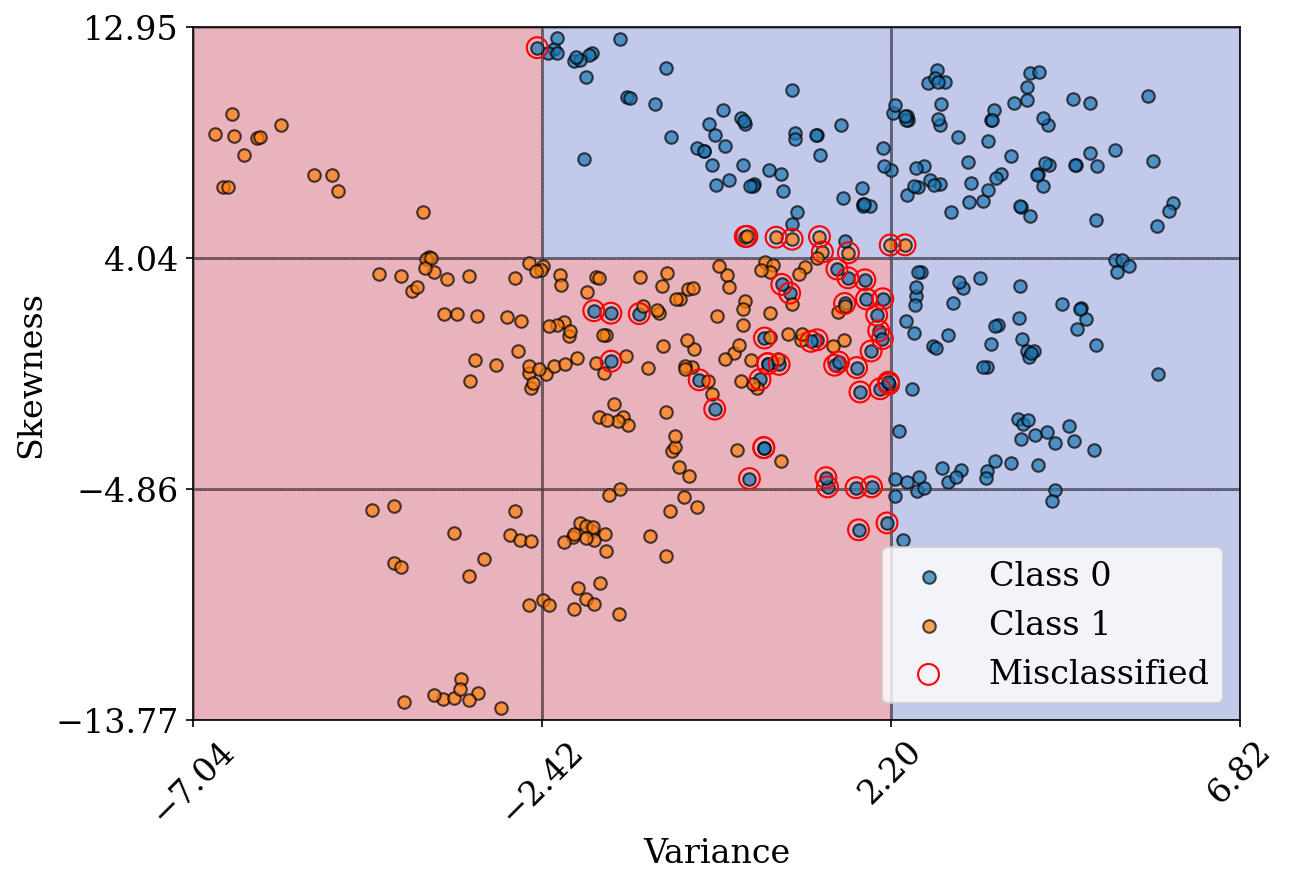

Bins 3x3: Accuracy = 0.88


In [5]:
# Split dataset into training (70%) and testing (30%) sets with fixed random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Train classifier with 3 bins
bins = 3  # Higher values = finer decision boundaries

# Get bin edges and trained model (class assignments per bin)
edges_x, edges_y, model = cubic_hist_classifier(X_train, y_train, bins)

# Predict classes for test data
y_pred = []
for x in X_test:
    # Find bin indices for current sample's features
    i = np.digitize(x[0], edges_x) - 1  # Subtract 1 for 0-based indexing
    j = np.digitize(x[1], edges_y) - 1
    # Ensure indices stay within bin array bounds and get predicted class
    y_pred.append(model[min(i, bins - 1), min(j, bins - 1)])

# Create grid based on bin edges
xx, yy = np.meshgrid(edges_x, edges_y)
Z = model.T  # Transpose to match meshgrid orientation

plt.figure()

# Plot each partition as discrete colored rectangle
plt.pcolormesh(xx, yy, Z, cmap='coolwarm', alpha=0.3, 
               edgecolor='k', linewidth=0.5, shading='auto')

# Add partition edge highlights
plt.grid(True, which='both', color='gray', linestyle=':', linewidth=0.5)
plt.xticks(edges_x, rotation=45)
plt.yticks(edges_y)

# Plot original data points
for label, color in zip([0, 1], ['blue', 'orange']):
    plt.scatter(X_test[y_test == label][:, 0], X_test[y_test == label][:, 1],
                label=f'Class {label}', edgecolor='k', alpha=0.7)

# Highlight misclassifications
misclassified = (np.array(y_pred) != y_test)
plt.scatter(X_test[misclassified][:, 0], X_test[misclassified][:, 1],
            facecolors='none', edgecolors='red', s=100,
            label='Misclassified')

plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.legend()
plt.show()

print(f"Bins {bins}x{bins}: Accuracy = {accuracy_score(y_test, y_pred):.2f}")

## Analysis:

1. Finer bins improve accuracy but risk overfitting (4x4 bins may memorize noise)
2. Computational complexity grows exponentially with dimensions (O(b^d))

# Problem 2

In [6]:
# Import necessary libraries
from sklearn.datasets import load_iris

# Load the Iris dataset
data = load_iris()
iris_df = pd.DataFrame(data.data, columns=data.feature_names)
iris_df['target'] = data.target

# Use only sepal features (first two columns)
X = iris_df.iloc[:, :2].values  # Sepal length and width
y = iris_df['target'].values

# Split the data in a 4:1 ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implement kNN with k=5 and Euclidean distance
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Create a mesh grid for visualization
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict on the mesh grid for decision boundary visualization
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

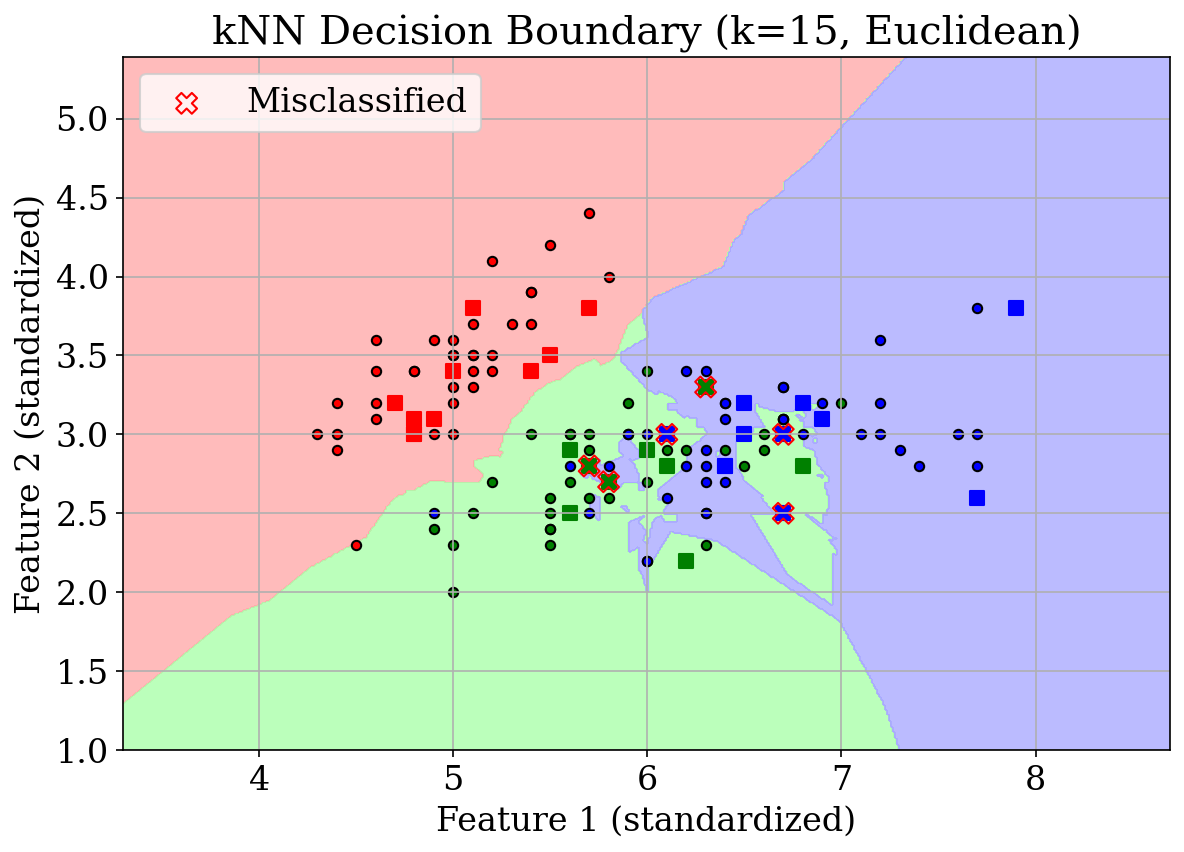

In [7]:
# Plot decision boundaries
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))

# Plot training points by class with circles ('o')
for i, color in zip(range(3), ['red', 'green', 'blue']):
    idx = np.where(y_train == i)
    plt.scatter(X_train[idx, 0], X_train[idx, 1], c=color, 
                marker='o', edgecolor='k', s=20)

# Plot testing points by class with crosses ('x')
for i, color in zip(range(3), ['red', 'green', 'blue']):
    idx = np.where(y_test == i)
    plt.scatter(X_test[idx, 0], X_test[idx, 1], c=color, 
                marker='s', s=50)

# Highlight misclassified points in red circles
misclassified = np.where(y_test != y_pred)
plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1], 
                marker='X', facecolors='none', edgecolors='red', s=100,
            label='Misclassified')

# Add title and labels
plt.title("kNN Decision Boundary (k=15, Euclidean)")
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.legend(loc='upper left')
plt.show()

In [8]:
# Confusion matrix and classification report for k=5
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (k=5):")
print(conf_matrix)
print("\nClassification Report (k=5):")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Confusion Matrix (k=5):
[[10  0  0]
 [ 0  6  3]
 [ 0  3  8]]

Classification Report (k=5):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.67      0.67      0.67         9
   virginica       0.73      0.73      0.73        11

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.80      0.80      0.80        30



Most confused classes are versicolor and virginica as there are overlap in sepal dimensions for these two classes.

In [9]:
# Fit kNN with k=15
knn_k15 = KNeighborsClassifier(n_neighbors=15, metric='euclidean')
knn_k15.fit(X_train, y_train)
y_pred_k15 = knn_k15.predict(X_test)

# Create a mesh grid for visualization
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict on the mesh grid for decision boundary visualization
Z = knn_k15.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

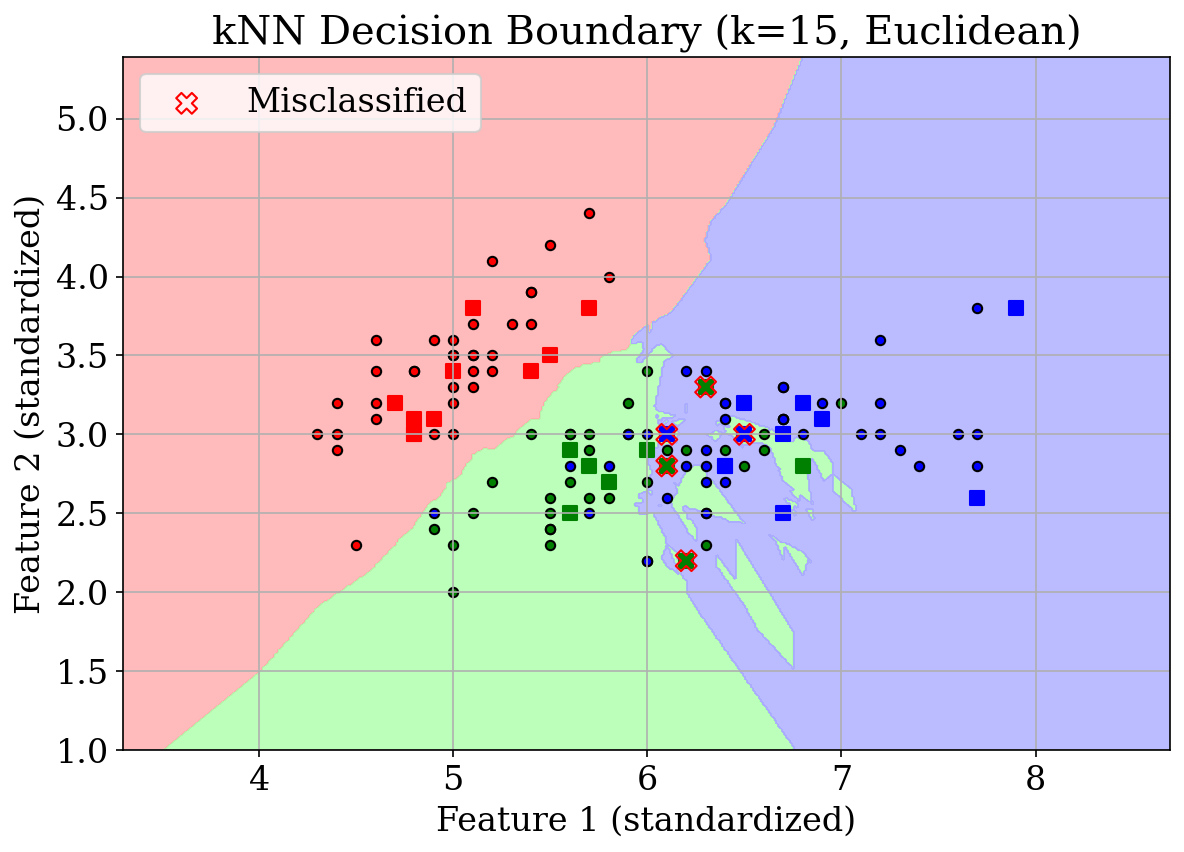

In [10]:
# Plot decision boundaries
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))

# Plot training points by class with circles ('o')
for i, color in zip(range(3), ['red', 'green', 'blue']):
    idx = np.where(y_train == i)
    plt.scatter(X_train[idx, 0], X_train[idx, 1], c=color, 
                marker='o', edgecolor='k', s=20)

# Plot testing points by class with crosses ('x')
for i, color in zip(range(3), ['red', 'green', 'blue']):
    idx = np.where(y_test == i)
    plt.scatter(X_test[idx, 0], X_test[idx, 1], c=color, 
                marker='s', s=50)

# Highlight misclassified points in red circles
misclassified = np.where(y_test != y_pred_k15)
plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1], 
                marker='X', facecolors='none', edgecolors='red', s=100,
            label='Misclassified')

# Add title and labels
plt.title("kNN Decision Boundary (k=15, Euclidean)")
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.legend(loc='upper left')
plt.show()


In [11]:
# Confusion matrix and classification report for k=15
conf_matrix_k15 = confusion_matrix(y_test, y_pred_k15)
class_report_k15 = classification_report(y_test, y_pred_k15, target_names=data.target_names)

print("\nConfusion Matrix (k=15):")
print(conf_matrix_k15)
print("\nClassification Report (k=15):")
print(class_report_k15)



Confusion Matrix (k=15):
[[10  0  0]
 [ 0  6  3]
 [ 0  2  9]]

Classification Report (k=15):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.75      0.67      0.71         9
   virginica       0.75      0.82      0.78        11

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.83        30
weighted avg       0.83      0.83      0.83        30



In [12]:
# Varying the distance metric to Manhattan distances
results = {}

# Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)
conf_matrix_manhattan = confusion_matrix(y_test, y_pred_manhattan)
class_report_manhattan = classification_report(y_test, y_pred_manhattan, target_names=data.target_names)
results['manhattan'] = (conf_matrix_manhattan, class_report_manhattan)

print("\nResults with Manhattan Distance:")
print(results['manhattan'][0])
print(results['manhattan'][1])



Results with Manhattan Distance:
[[10  0  0]
 [ 0  6  3]
 [ 0  3  8]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.67      0.67      0.67         9
   virginica       0.73      0.73      0.73        11

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.80      0.80      0.80        30



# Problem 3

In [13]:
# Load & preprocess data
source = 'abalone.csv'
df = pd.read_csv(source, header=None)
X = df.iloc[:,1:8].values  # Physical measurements
y = (df[8] >= 10).astype(int)  # Binary classification: age ≥10

# Normalize
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Test configurations
configs = {
    'manhattan_uniform': {'metric':'manhattan', 'weights':'uniform'},
    'manhattan_inverse': {'metric':'manhattan', 'weights':'distance'},
    'cosine_uniform': {'metric':'cosine', 'weights':'uniform'},
    'cosine_inverse': {'metric':'cosine', 'weights':'distance'}
}

for name, params in configs.items():
    knn = KNeighborsRegressor(n_neighbors=15, **params)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    print(f"{name}: R² = {acc:.3f}")


manhattan_uniform: R² = 0.400
manhattan_inverse: R² = 0.403
cosine_uniform: R² = 0.406
cosine_inverse: R² = 0.399


# Problem 4

In [14]:
from sklearn.datasets import make_classification

class KernelClassifier:
    def __init__(self, kernel_name, bandwidth=1.0):
        self.kernel_name = kernel_name
        self.bandwidth = bandwidth
        self.kernel_func = self.get_kernel_function(kernel_name)
    
    def get_kernel_function(self, kernel_name):
        """Returns the appropriate kernel function based on the name."""
        if kernel_name == 'gaussian':
            return lambda x, xi: np.exp(-np.linalg.norm((x - xi) / self.bandwidth)**2)
        elif kernel_name == 'cauchy':
            return lambda x, xi: 1 / (1 + np.linalg.norm((x - xi) / self.bandwidth)**3)
        elif kernel_name == 'uniform':
            return lambda x, xi: 1 if np.linalg.norm((x - xi) / self.bandwidth) <= 1 else 0
        elif kernel_name == 'triangular':
            return lambda x, xi: max(0, 1 - np.linalg.norm((x - xi) / self.bandwidth))
        elif kernel_name == 'epanechnikov':
            return lambda x, xi: max(0, 1 - np.linalg.norm((x - xi) / self.bandwidth)**2)
        elif kernel_name == 'cubic':
            return lambda x, xi: max(0, 1 - np.linalg.norm((x - xi) / self.bandwidth)**3)
        else:
            raise ValueError(f"Unknown kernel name: {kernel_name}")
    
    def fit(self, X_train, y_train):
        """Stores the training data."""
        self.X_train = X_train
        self.y_train = y_train
    
    def predict(self, X_test):
        """Predicts labels for the test data."""
        y_pred = []
        for x in X_test:
            class_scores = {}
            for label in np.unique(self.y_train):
                class_scores[label] = sum(
                    self.kernel_func(x, xi) for xi, yi in zip(self.X_train, self.y_train) if yi == label
                )
            # Assign to the class with the highest score
            y_pred.append(max(class_scores, key=class_scores.get))
        return np.array(y_pred)
    
    def evaluate(self, X_test, y_test):
        """Evaluates the classifier accuracy."""
        y_pred = self.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        return accuracy

# Visualization function
def visualize_results(X_train, y_train, X_test, y_test, y_pred):
    plt.figure(figsize=(8, 6))
    
    # Plot training data
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', marker='o', label='Train Data', edgecolor='k')
    
    # Plot test data with predictions
    for i, x in enumerate(X_test):
        color = 'blue' if y_pred[i] == y_test[i] else 'red'
        label = 'Correctly Classified' if y_pred[i] == y_test[i] else 'Misclassified'
        plt.scatter(x[0], x[1], c=color, marker='x', label=label)
    
    plt.title('Kernel Classifier Results')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


In [15]:
# Generate synthetic data
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [16]:
# Instantiate classifier with Gaussian kernel
classifier = KernelClassifier(kernel_name='gaussian', bandwidth=0.1)

# Train classifier on training data
classifier.fit(X_train, y_train)

# Predict and evaluate on test data
y_pred = classifier.predict(X_test)
accuracy = classifier.evaluate(X_test, y_test)

print(f"Accuracy with Gaussian Kernel: {accuracy}")


Accuracy with Gaussian Kernel: 0.8666666666666667


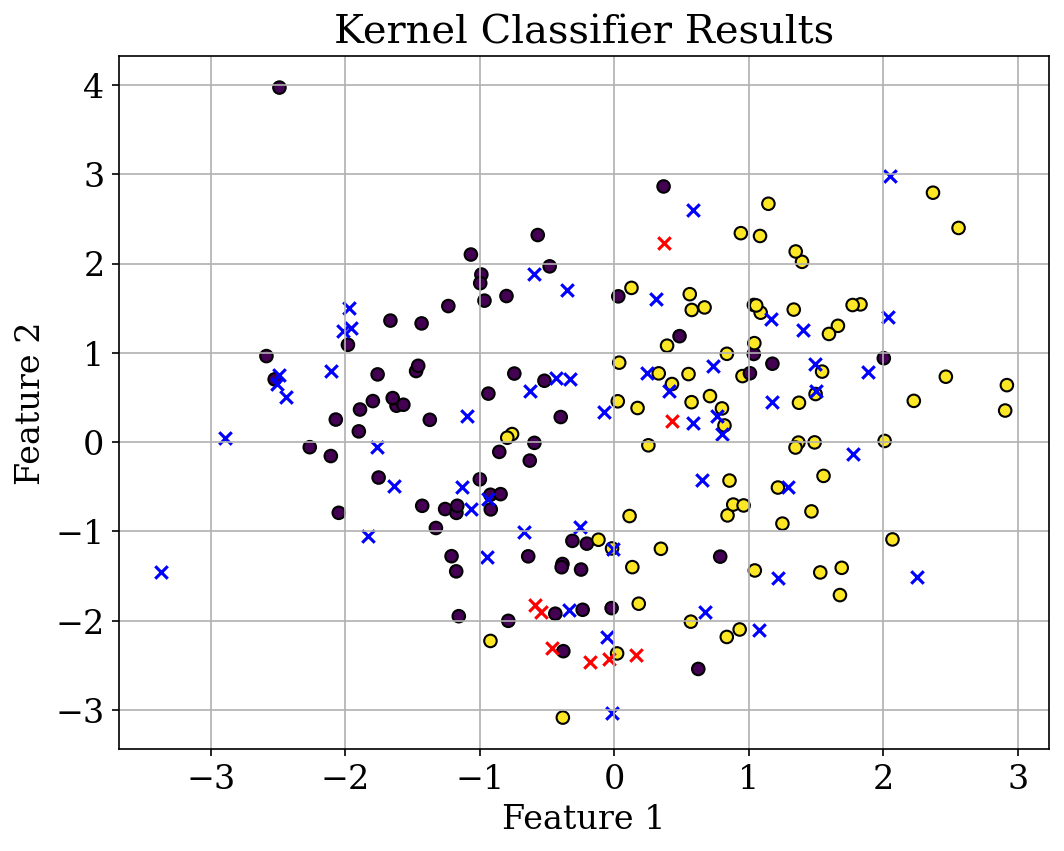

In [17]:
# Visualize classification results
visualize_results(X_train, y_train, X_test, y_test, y_pred)


Accuracy with Epanechnikov Kernel: 0.6333333333333333


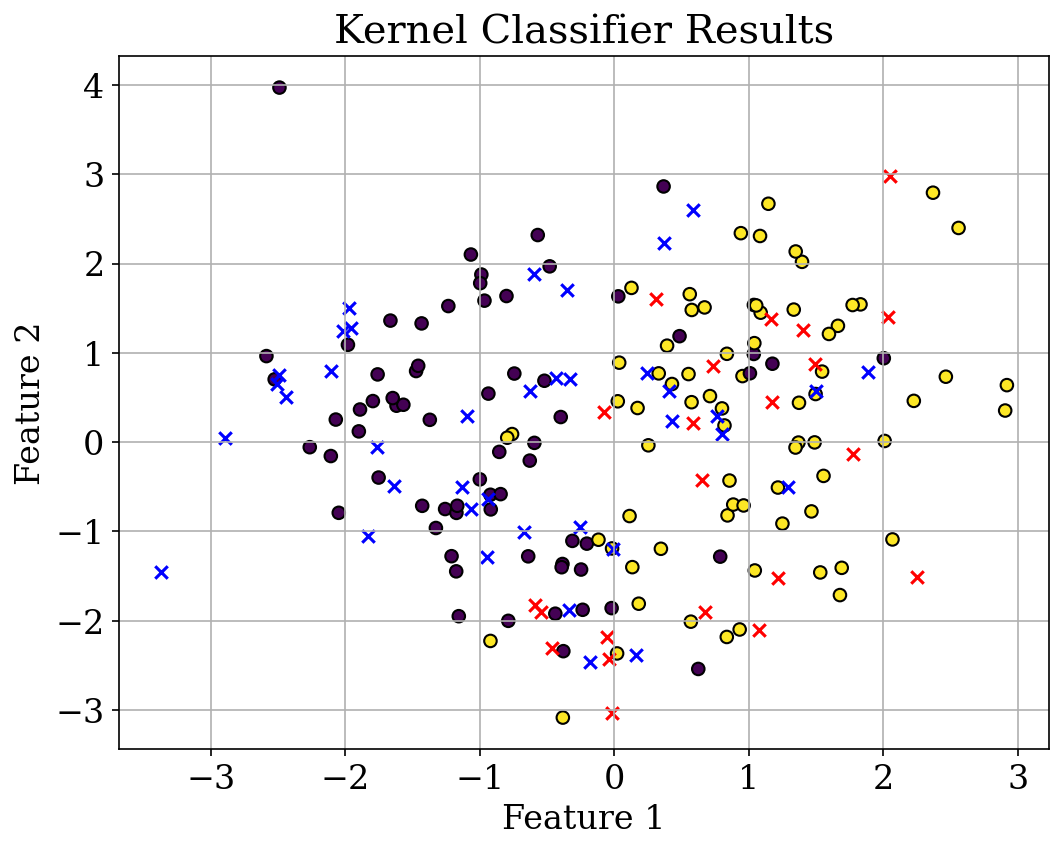

In [18]:
# Test with Epanechnikov Kernel
classifier_epanechnikov = KernelClassifier(kernel_name='epanechnikov', bandwidth=0.1)
classifier_epanechnikov.fit(X_train, y_train)
y_pred_epanechnikov = classifier_epanechnikov.predict(X_test)
accuracy_epanechnikov = classifier_epanechnikov.evaluate(X_test, y_test)

print(f"Accuracy with Epanechnikov Kernel: {accuracy_epanechnikov}")
visualize_results(X_train, y_train, X_test, y_test, y_pred_epanechnikov)
